In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"D:\practice files\telcom_churndataset.csv")

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# columns meaning in easy words:
# 📊 Telecom Customer Churn Dataset - Feature Description

## Basic Customer Information
- **customerID**  
  Unique ID for each customer. Used only for identification, not useful for analysis.

- **gender**  
  Customer’s gender (Male / Female).

- **SeniorCitizen**  
  Indicates if the customer is a senior citizen.  
  - 1 = Yes  
  - 0 = No  

- **Partner**  
  Whether the customer has a partner.  
  - Yes / No  

- **Dependents**  
  Whether the customer has dependents (children or others).  
  - Yes / No  


## Customer Relationship
- **tenure**  
  Number of months the customer has stayed with the company.  
  Higher tenure usually means a more loyal customer.


## Services Used
- **PhoneService**  
  Whether the customer uses phone service.  
  - Yes / No  

- **MultipleLines**  
  Whether the customer has multiple phone lines.  
  - Yes → Customer has multiple phone lines
- No → Customer has only one phone line
- No phone service → Customer does not have any phone service 

- **InternetService**  
  Type of internet service used.  
  - DSL  
  - Fiber optic  
  - No  

- **OnlineSecurity**  
  Whether the customer has online security service.  
  - Yes / No / No internet service  

- **OnlineBackup**  
  Whether the customer uses online backup service.
- Yes → Backup service is active
- No → Customer has internet but not using backup
- No internet service → Customer does not have internet  
  -  

- **DeviceProtection**  
  Whether the customer has device protection service.  
- Yes → Protection active
- No → Has internet but not using it
- No internet service → No internet → cannot use protection 

- **TechSupport**  
  Whether the customer has technical support access.  
  - Yes / No / No internet service  

- **StreamingTV**  
  Whether the customer uses TV streaming service.  
  - Yes / No / No internet service  

- **StreamingMovies**  
  Whether the customer uses movie streaming service.  
  - Yes / No / No internet service  


## Contract & Billing
- **Contract**  
  Type of contract the customer has.  
  - Month-to-month (higher churn risk)  
  - One year  
  - Two year (lower churn risk)  

- **PaperlessBilling**  
  Whether the customer uses paperless billing.  
  - Yes / No  

- **PaymentMethod**  
  Payment method used by the customer.  
  Examples:  
  - Electronic check  
  - Mailed check  
  - Bank transfer  
  - Credit card  


## Financial Information
- **MonthlyCharges**  
  Amount the customer pays every month.

- **TotalCharges**  
  Total amount paid by the customer so far.  
  Depends on tenure and monthly charges.


## Target Variable
- **Churn**  
  Whether the customer left the company or not.  
  - Yes = Customer left  
  - No = Customer stayed  

# hypothesis:
- **contract affects churn**,monthly customers are likely to churn, whereas a persons with contract of 2 or more years are less likely to churn.
- **Lack of support** causes churn.
- **Higher Charges Increase Churn**
- **tenure** affect the churn,the less no of months the person stayed with the company,the more likely he/she is to churn and vice versa.
- **more services used mean customer is highly connected,less changes of churn.**

In [4]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# no missing values found

In [44]:
# Drop customerID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [45]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Total Numerical Columns ({len(numerical_cols)}): \n{numerical_cols}")
print("*" * 30)
print(f"Total Categorical Columns ({len(categorical_cols)}): \n{categorical_cols}")

Total Numerical Columns (4): 
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
******************************
Total Categorical Columns (16): 
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [46]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("-"*40)

Column: gender
gender
Male      3549
Female    3483
Name: count, dtype: int64
----------------------------------------
Column: SeniorCitizen
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64
----------------------------------------
Column: Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64
----------------------------------------
Column: Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
----------------------------------------
Column: tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
38     59
28     57
39     56
44     51
36     50
Name: count, Length: 72, dtype: int64
----------------------------------------
Column: PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
----------------------------------------
Column: MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
----------------------------------------
Column: 

In [47]:
df.duplicated().sum()        # now duplicate rows found.

22

# UNIVARIATE ANALYSIS

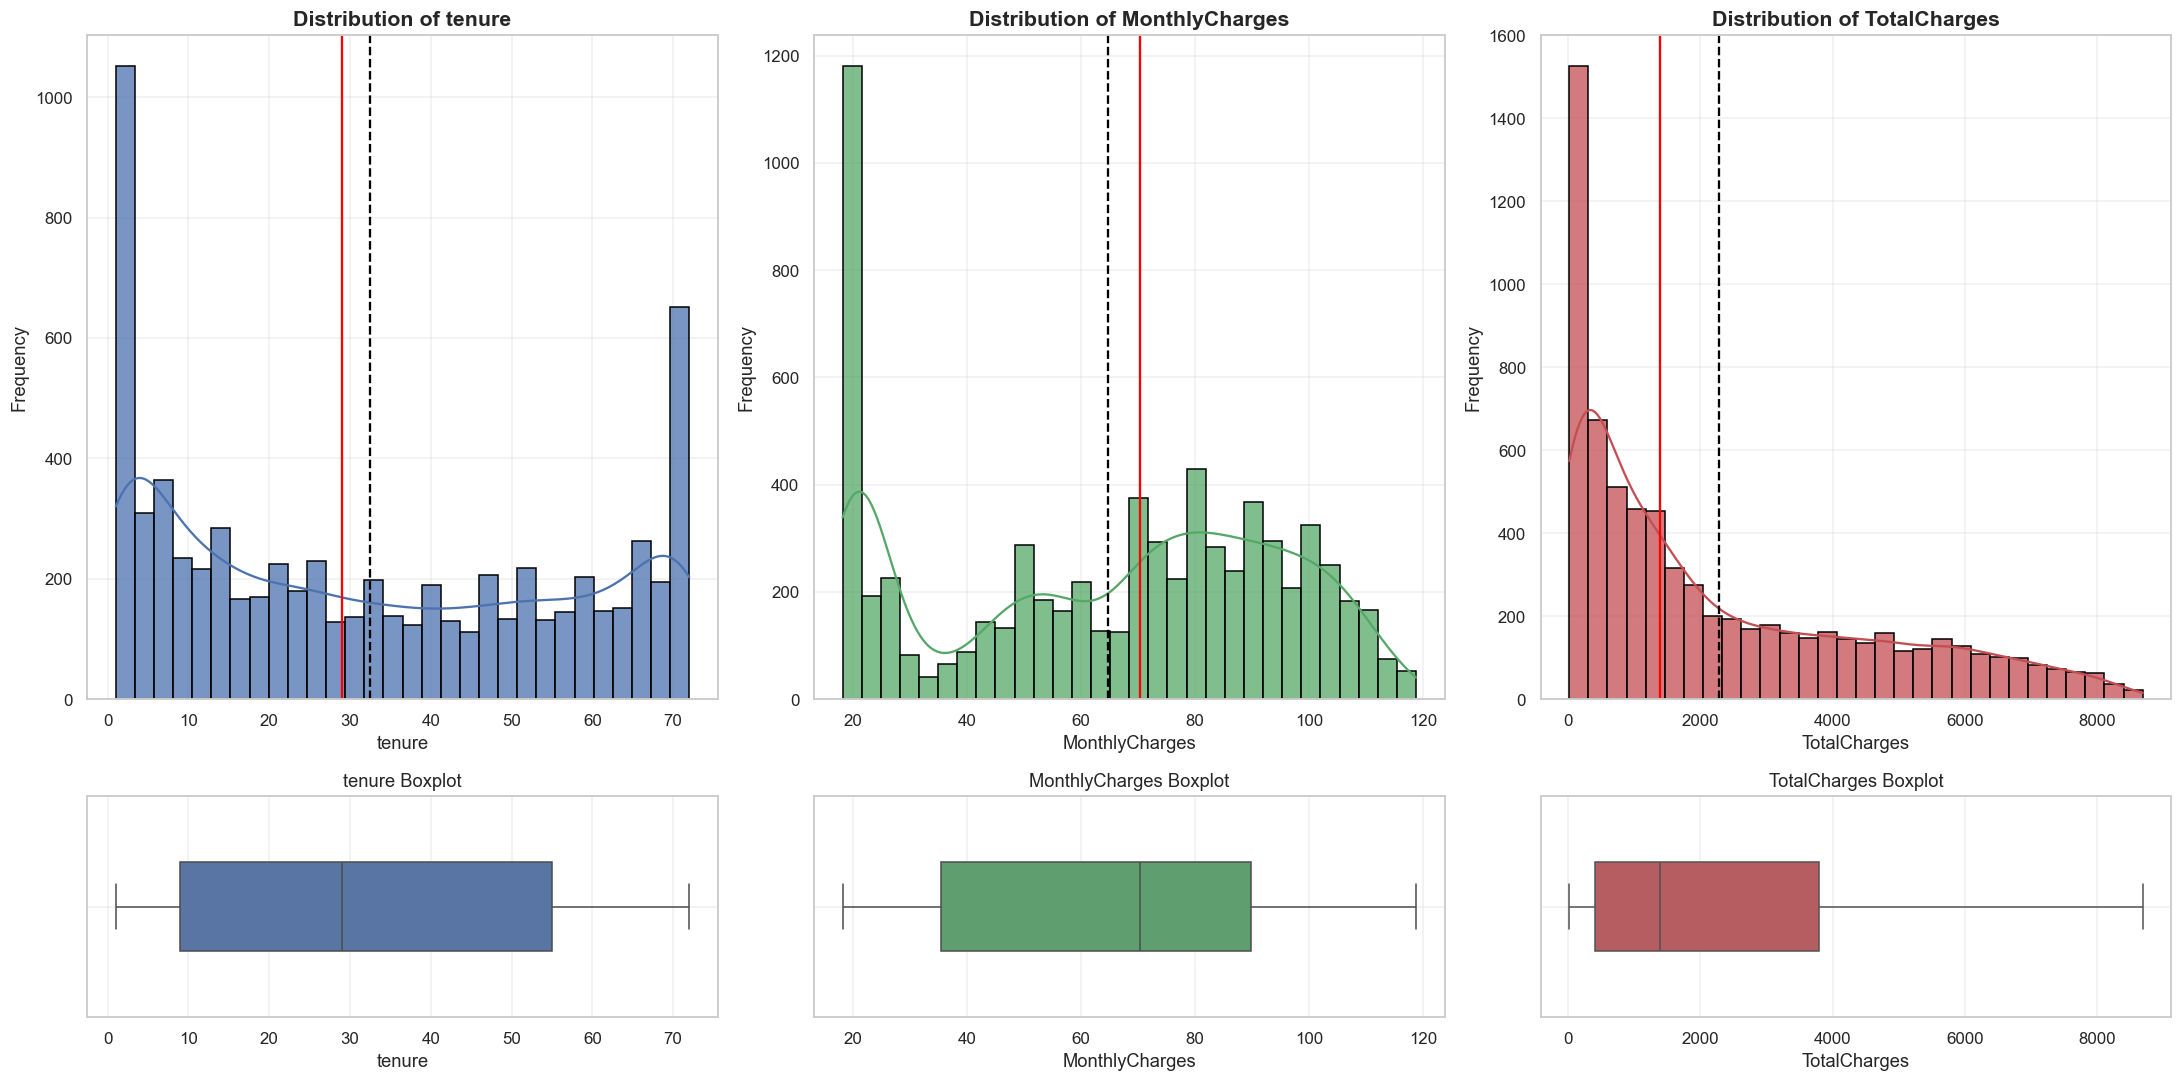

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 3, figsize=(20, 10), gridspec_kw={'height_ratios': [3, 1]})

for i, col in enumerate(num_cols):
  
    data = df[col].dropna()

    if data.empty:
        continue
    

    sns.histplot(
        data,
        kde=True,
        bins=30,
        ax=axes[0, i],
        color=colors[i],
        edgecolor='black',
        alpha=0.75
    )
    

    mean_val = data.mean()
    median_val = data.median()
    
    axes[0, i].axvline(mean_val, color='black', linestyle='--', linewidth=1.5)
    axes[0, i].axvline(median_val, color='red', linestyle='-', linewidth=1.5)
    
    axes[0, i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].grid(alpha=0.3)
    
    sns.boxplot(
        x=data,
        ax=axes[1, i],
        color=colors[i],
        width=0.4
    )
    
    axes[1, i].set_title(f'{col} Boxplot', fontsize=12)
    axes[1, i].set_xlabel(col)
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Tenure** :the data has two peaks, the first inital spike are the new customers and  the second one at the last are the loyal customers.


 2. if the customers don't leave in the initial months ,they tend to stay for years.


3.mean is higher than median, it happens because those loyal (70+) customers are so loyal that they are dragging the mean upwards.


**monthly charges**:The 20 peak represents "Entry-level" users (likely landline only or basic DSL). The 70-100 group represents "Premium" users (Fiber optic, multiple streams, and security add-ons).
- there is a dip in charges between 30 and 60, which indicate that the  customers are  either using the basic service or the premieum service, they are hesitant to take the mid level plans which according to them are not able to give enough value to justify the price jump from the basic plan.

**Total charges**: the  customers above 8000 are "Diamond" customers. High Tenure (been here for years) and High Monthly Charges (premium plans). While they are fewer in number, they likely provide a huge portion of the company's total revenue.
- 75% of the customers have spent less than 3800-3900.

C:\Users\Asus\AppData\Local\Temp\ipykernel_31012\4213633523.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_31012\4213633523.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_31012\4213633523.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_31012\4213633523.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to 

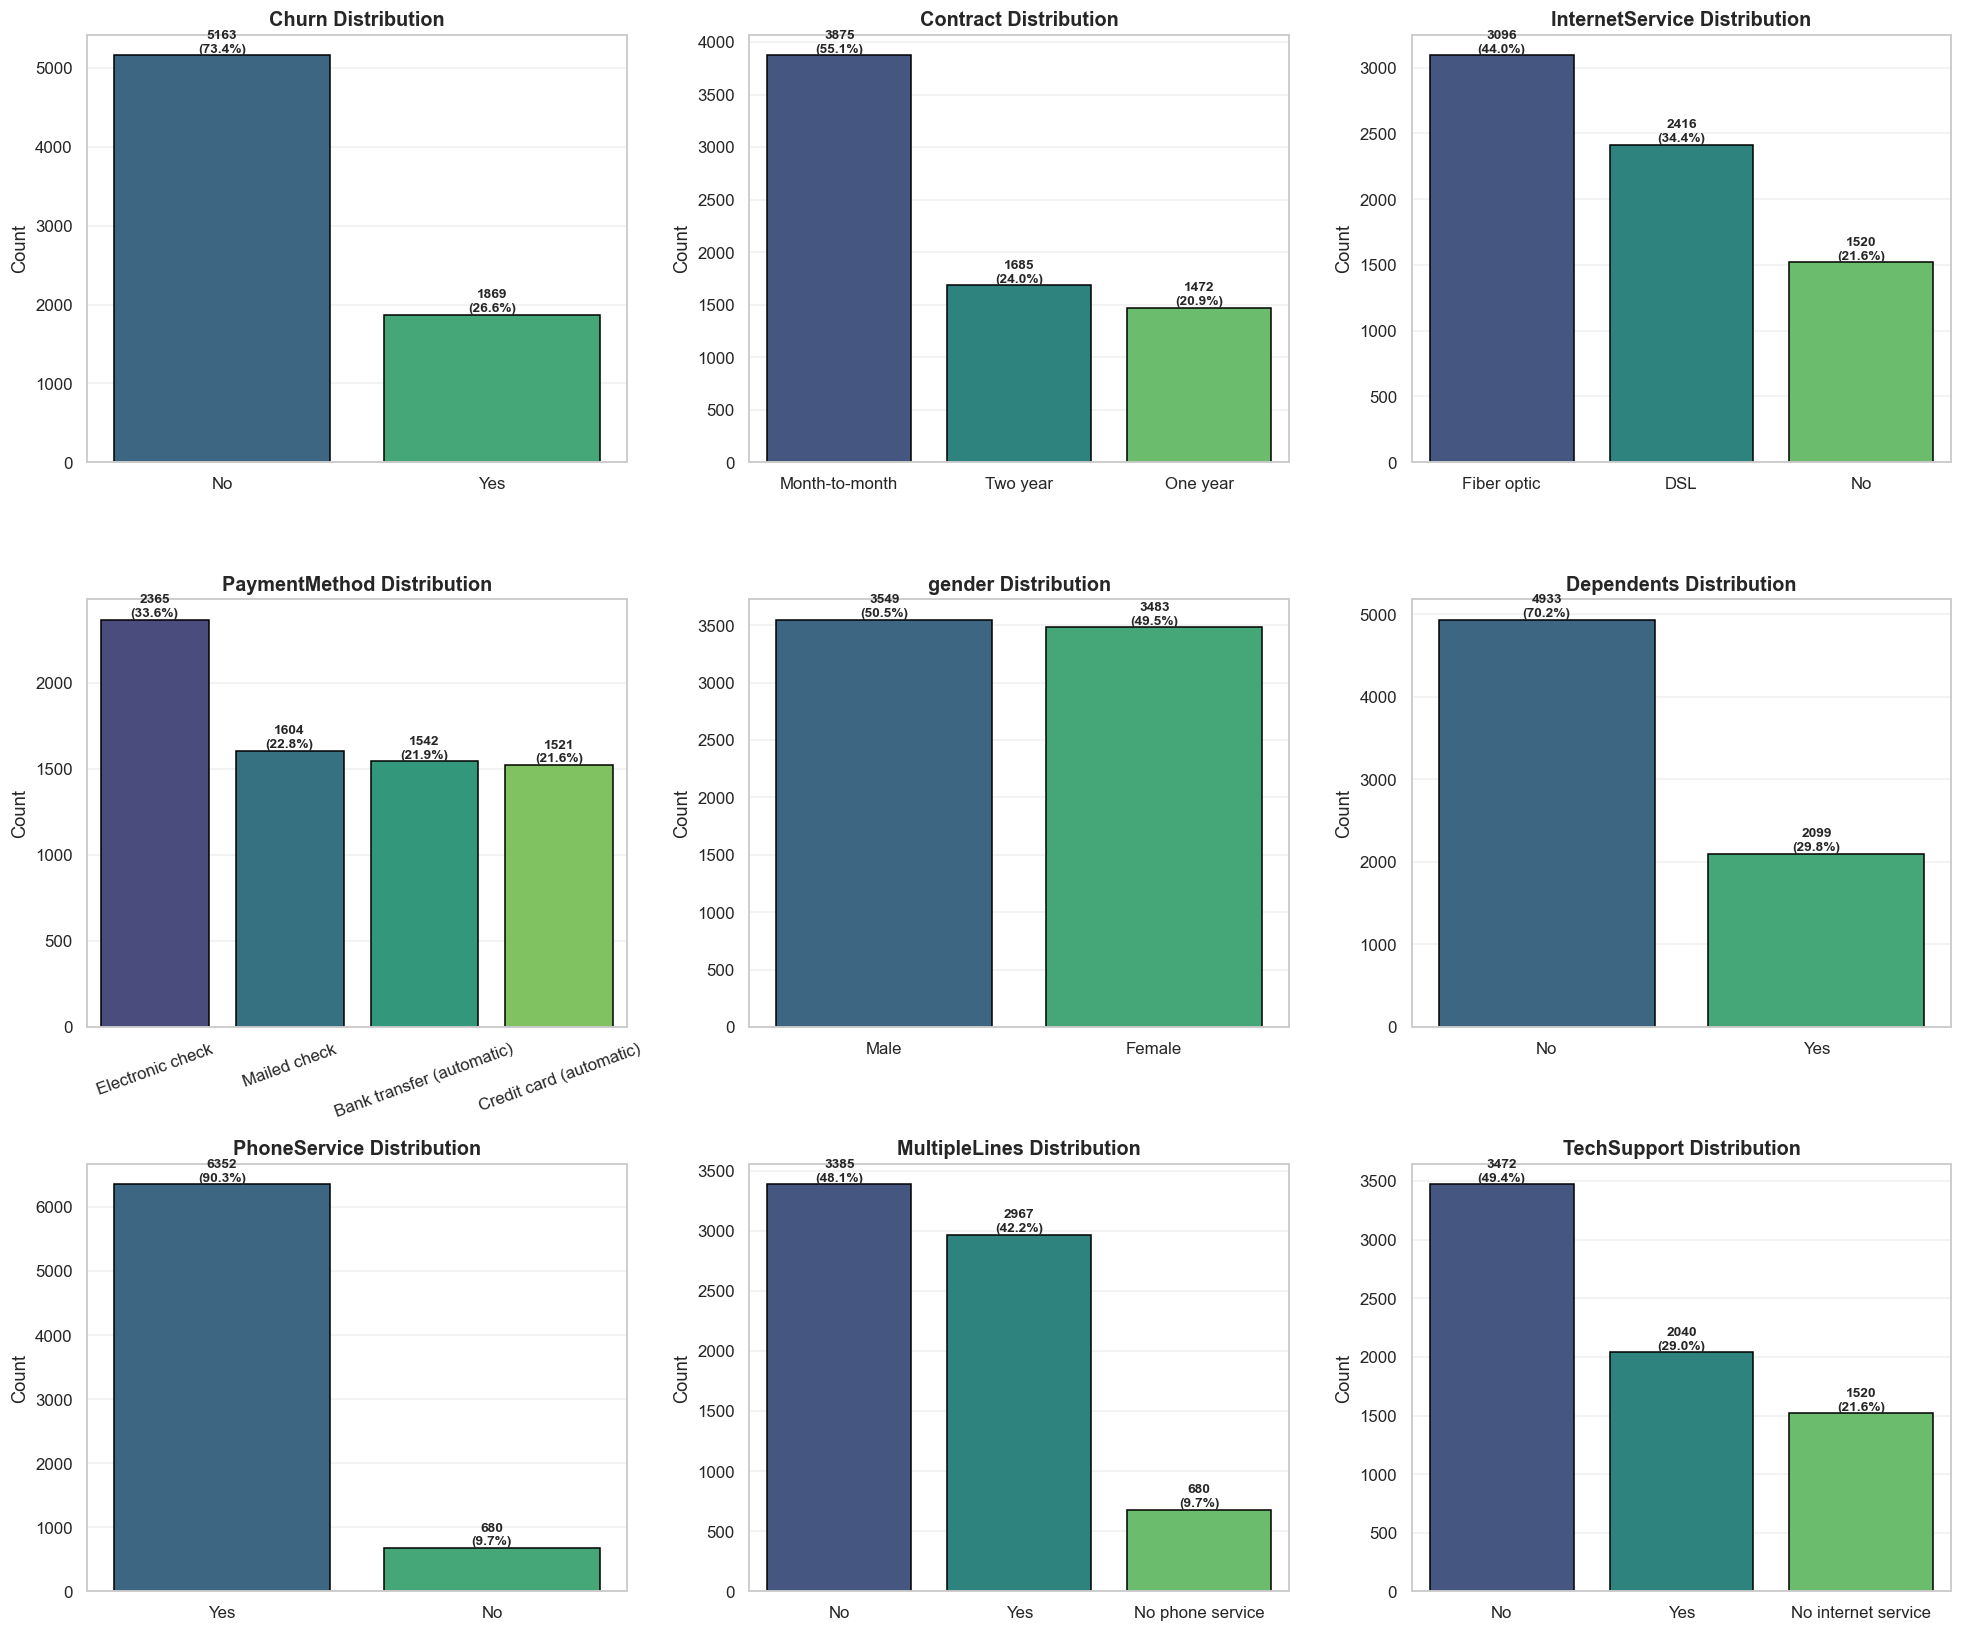

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

cat_cols = [
    'Churn', 'Contract', 'InternetService', 'PaymentMethod',
    'gender', 'Dependents', 'PhoneService', 'MultipleLines', 'TechSupport'
]


n_cols = 3   
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    # Handle missing safely
    data = df[col].fillna('Missing')
    
    order = data.value_counts().index
    
    sns.countplot(
        x=data,
        order=order,
        ax=axes[i],
        palette='viridis',
        edgecolor='black'
    )
    
    total = len(data)
    
    for p in axes[i].patches:
        count = int(p.get_height())
        percentage = 100 * count / total
        
        axes[i].annotate(
            f'{count}\n({percentage:.1f}%)',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )
    
    axes[i].set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    
    if len(order) > 3:
        axes[i].tick_params(axis='x', rotation=20)
    
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Contract Risk:** 55% of customers are on Month-to-month contracts. This represents the highest risk segment for the business as they have no long-term financial commitment.

**Gender Balance:** The customer base is almost perfectly split between Male (50.5%) and Female (49.5%), indicating the service has universal appeal across genders.

**Phone Dominance:** Over 90.3% of the customer base uses Phone Service, making it the most ubiquitous offering in the portfolio.

**Internet Preferences:** Fiber Optic is the leading internet choice (44%), followed by DSL (34.4%). A significant 21.7% of the base does not use company internet services.
- Only 29% of customers utilize Tech Support, suggesting a major opportunity for service expansion.

- A vast majority of customers (70%) report having no dependents, suggesting the primary target audience consists of individuals or couples.
  
**The overall churn rate sits at 26.5%.**

**Strategic Focus:** the primary  objective should be identifying if the high volume of "Month-to-month" contracts and "Fiber Optic" users are the primary drivers behind this number.

# bivariate analysis:

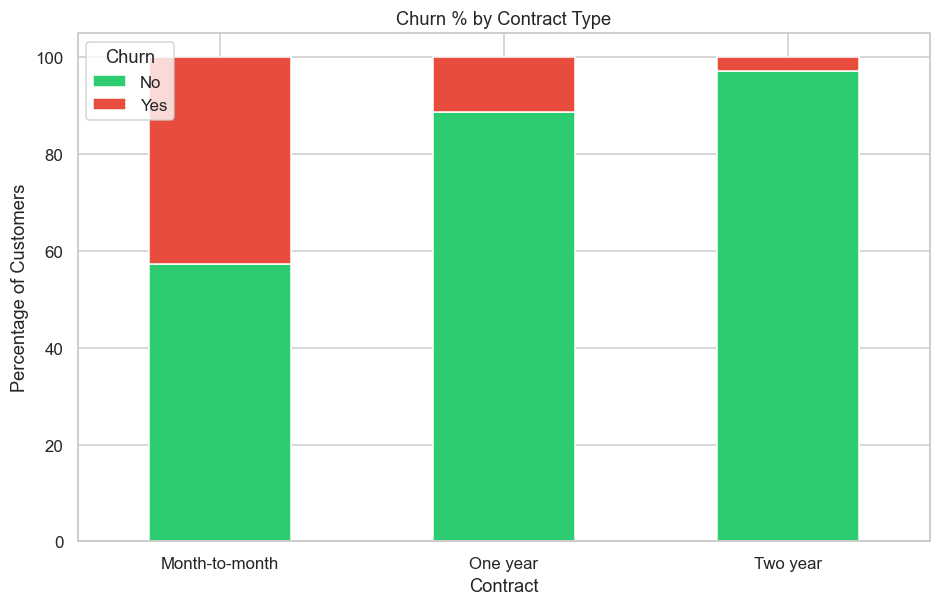

In [59]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.plot(
    kind='bar',
    stacked=True,
    color=['#2ecc71', '#e74c3c'],
    figsize=(10,6)
)

plt.title('Churn % by Contract Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

- Month-to-month customers show the highest churn risk.
- Long-term contracts significantly improve retention.
- One-year and two-year contracts stabilize customer loyalty.

# Internet Service vs Churn

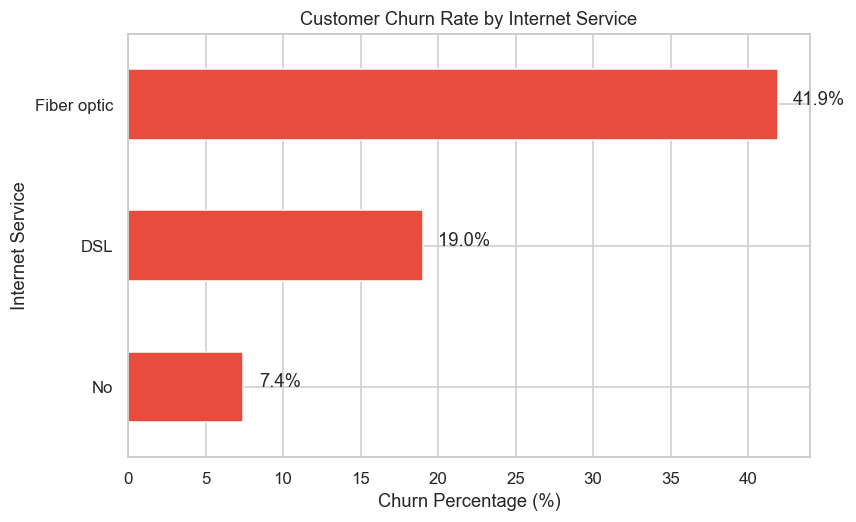

In [93]:
churn_rate = (
    pd.crosstab(
        df['InternetService'],
        df['Churn'],
        normalize='index'
    )['Yes'] * 100
)

churn_rate = churn_rate.sort_values()

plt.figure(figsize=(8,5))

churn_rate.plot(
    kind='barh',
    color='#e74c3c'
)

plt.xlabel('Churn Percentage (%)')
plt.ylabel('Internet Service')
plt.title('Customer Churn Rate by Internet Service')

for index, value in enumerate(churn_rate):
    plt.text(value + 1, index, f'{value:.1f}%')

plt.show()

- Fiber optic customers churn the most.
- DSL customers are comparatively more stable.
- Higher churn in fiber users may indicate pricing or service-quality issues.

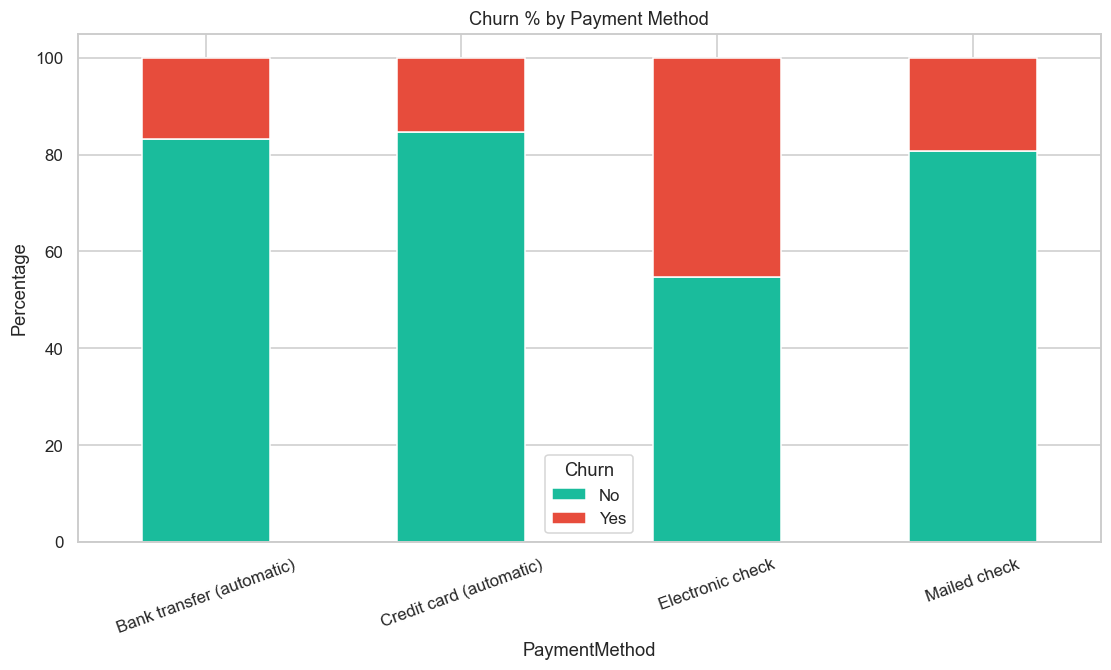

In [62]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

payment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['#1abc9c', '#e74c3c']
)

plt.title('Churn % by Payment Method')
plt.ylabel('Percentage')
plt.xticks(rotation=20)
plt.show()

- Electronic check users show the highest churn.
- Automatic payment methods retain customers better.
- Payment automation correlates with customer stability.

C:\Users\Asus\AppData\Local\Temp\ipykernel_31012\3192854143.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


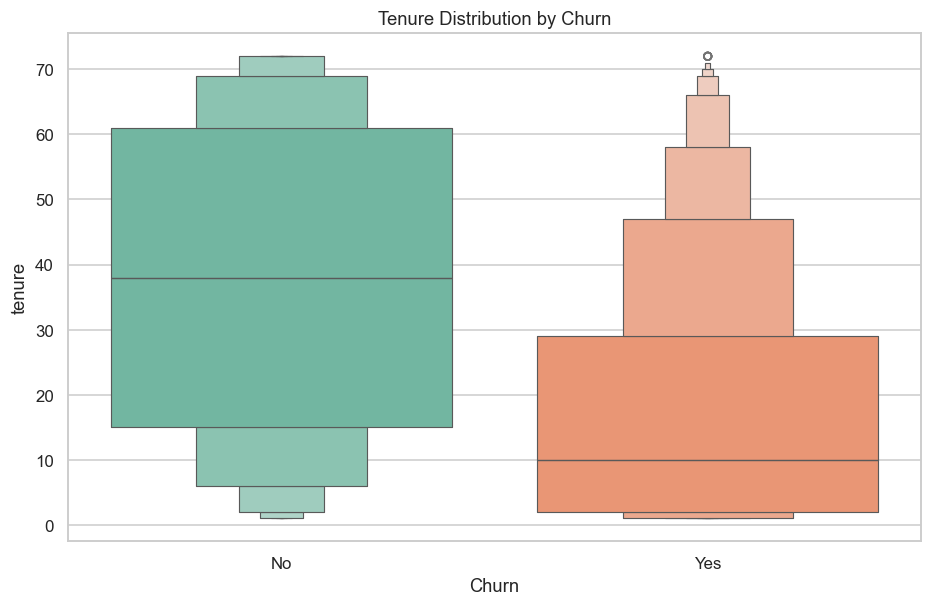

In [63]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    data=df,
    x='Churn',
    y='tenure',
    palette='Set2'
)

plt.title('Tenure Distribution by Churn')
plt.show()

- Customers who churn usually have very low tenure.
- people are leaving almost the moment they sign up.
- Long-term customers rarely leave.
- Retention efforts should focus on the first few months.

C:\Users\Asus\AppData\Local\Temp\ipykernel_31012\771068723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


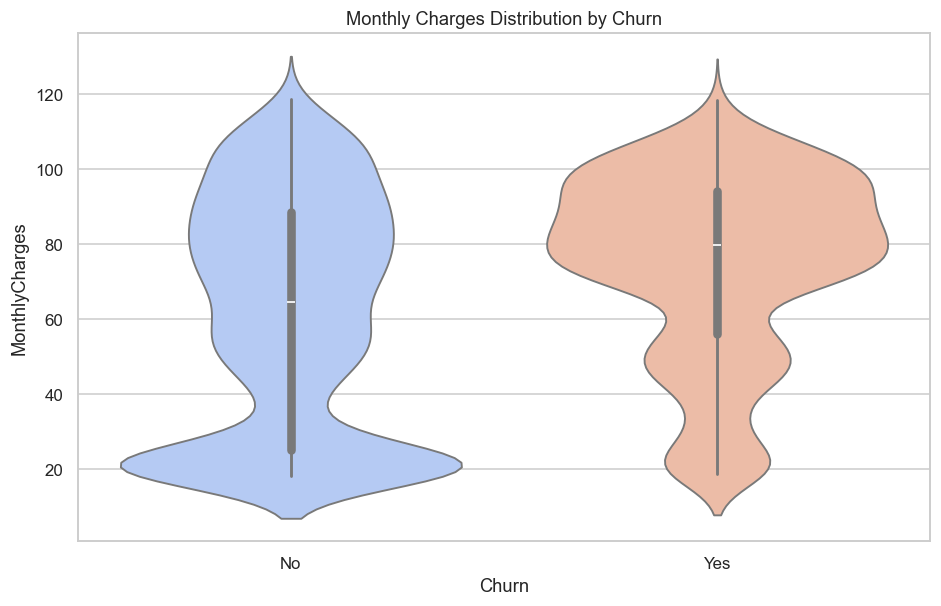

In [64]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Churn',
    y='MonthlyCharges',
    palette='coolwarm'
)

plt.title('Monthly Charges Distribution by Churn')
plt.show()

- Churned customers generally pay higher monthly charges, which meansExpensive plans experience higher dissatisfaction.
- most loyal customers are on cheap plans.
- Pricing sensitivity strongly affects retention.
- High-value customers are also high-risk customers.


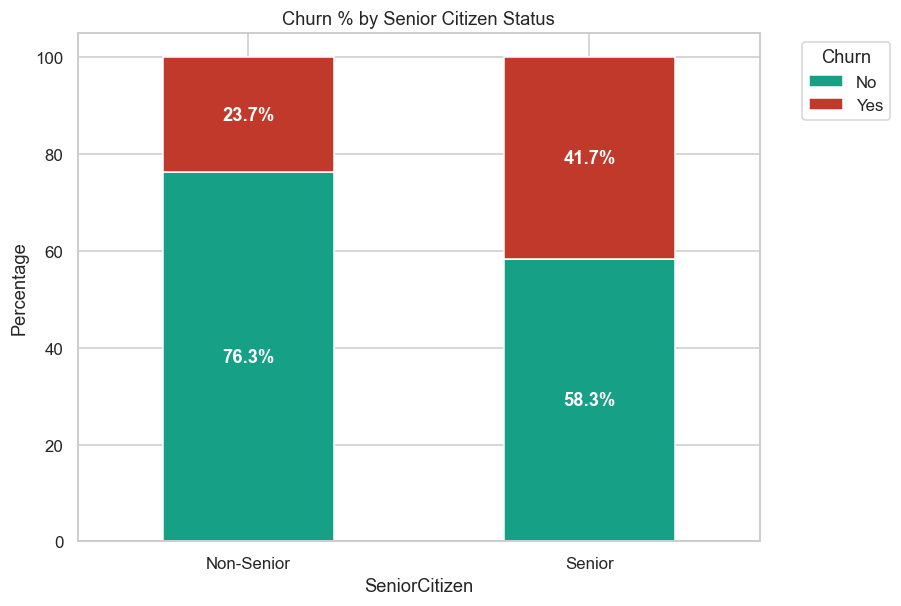

In [68]:
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100


ax = senior_churn.plot(
    kind='bar',
    stacked=True,
    color=['#16a085', '#c0392b'],
    figsize=(8, 6)
)


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')
plt.title('Churn % by Senior Citizen Status')
plt.xticks([0, 1], ['Non-Senior', 'Senior'], rotation=0)
plt.ylabel('Percentage')
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside
plt.show()

- Senior citizens churn more frequently.
- Customer service quality may significantly impact retention.

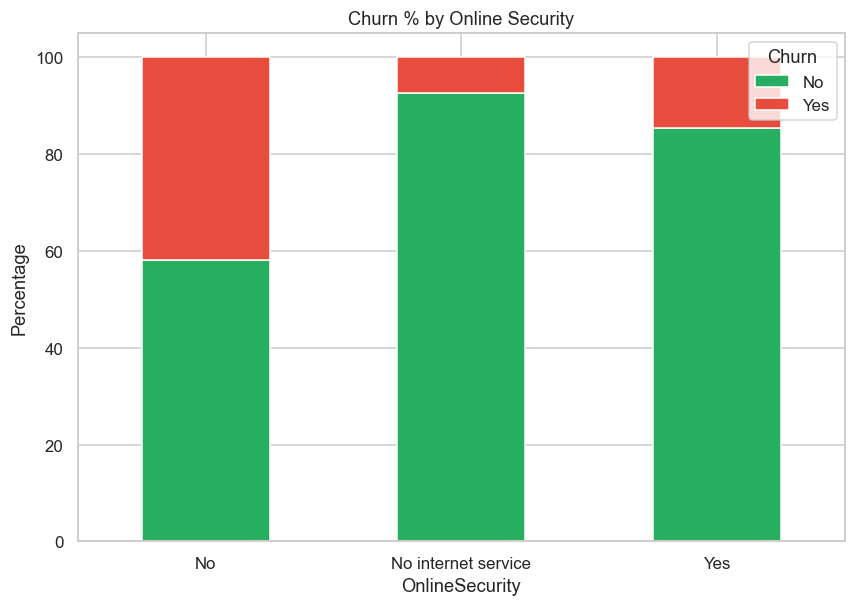

In [79]:
security_churn = (
    pd.crosstab(
        df['OnlineSecurity'],
        df['Churn'],
        normalize='index'
    ) * 100
)

security_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(9,6),
    color=['#27ae60', '#e74c3c']
)

plt.title('Churn % by Online Security')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')

plt.show()

- Customers without online security churn significantly more.
- Security services increase customer stickiness.
- Customers using more services are less likely to leave.

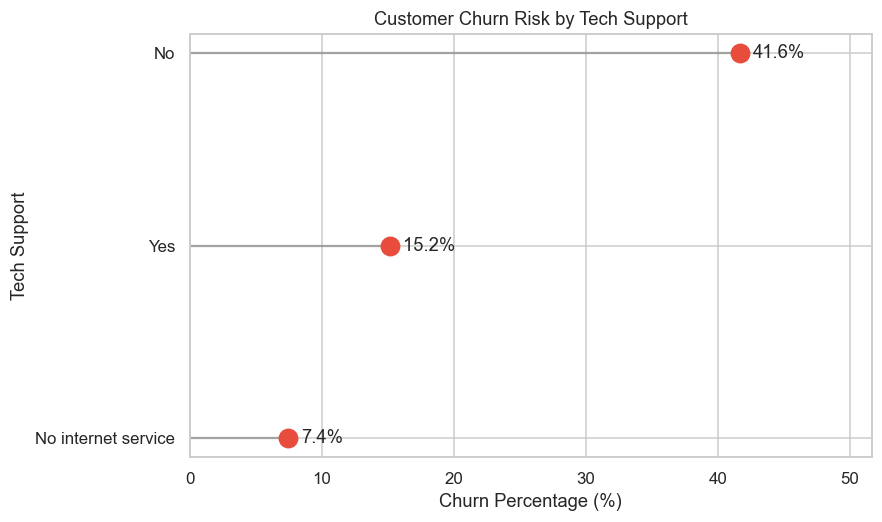

In [99]:
support_churn_rate = (
    pd.crosstab(
        df['TechSupport'],
        df['Churn'],
        normalize='index'
    )['Yes'] * 100
).sort_values()


plt.figure(figsize=(8,5))


plt.hlines(
    y=support_churn_rate.index,
    xmin=0,
    xmax=support_churn_rate.values,
    color='gray',
    alpha=0.6
)

plt.plot(
    support_churn_rate.values,
    support_churn_rate.index,
    'o',
    markersize=12,
    color='#e74c3c'
)

for i, value in enumerate(support_churn_rate.values):
    plt.text(
        value + 1,
        i,
        f'{value:.1f}%',
        va='center'
    )

plt.xlabel('Churn Percentage (%)')
plt.ylabel('Tech Support')
plt.title('Customer Churn Risk by Tech Support')

plt.xlim(0, max(support_churn_rate.values) + 10)

plt.show()

- Customers lacking tech support churn at much higher rates.
- Technical assistance strongly improves retention.
- Tech support behaves like a protective churn factor.

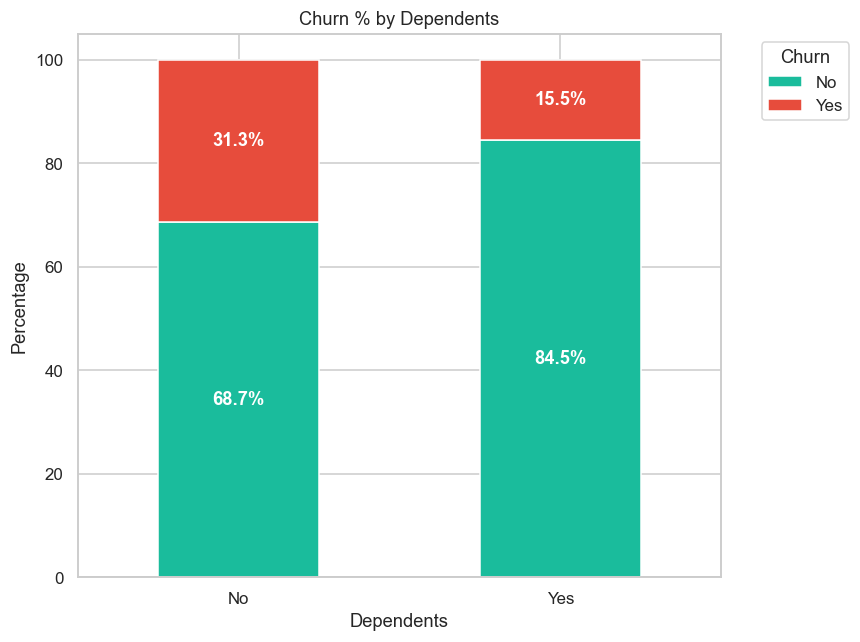

In [85]:
dependent_churn = (
    pd.crosstab(
        df['Dependents'],
        df['Churn'],
        normalize='index'
    ) * 100
)

ax = dependent_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    color=['#1abc9c', '#e74c3c']
)


for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.1f%%', 
        label_type='center', 
        color='white', 
        fontweight='bold'
    )

plt.title('Churn % by Dependents')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() 
plt.show()

- Customers with dependents churn much less.
- Family-linked customers are more stable.
- Household responsibility increases service continuity.
- Single-person accounts are higher churn risks

# multivariate analysis:

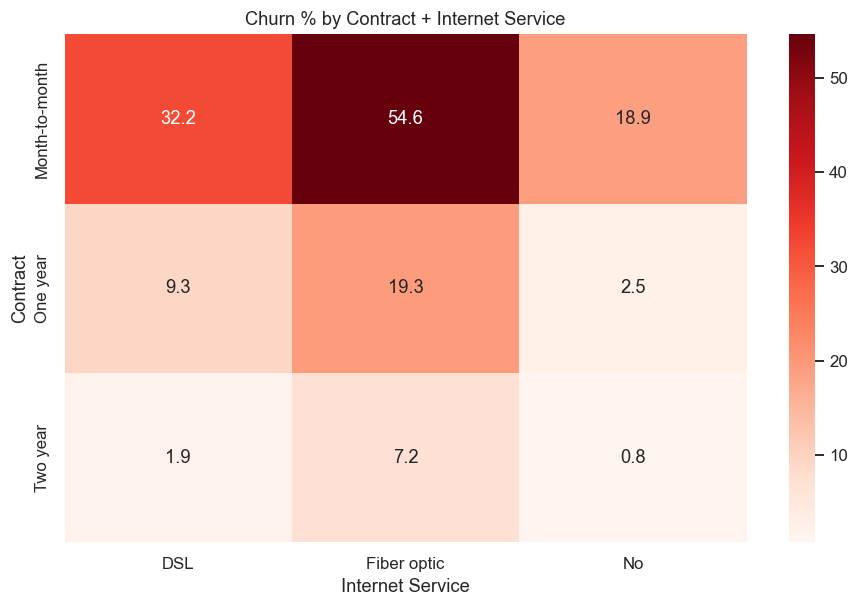

In [73]:
combo = (
    df.groupby(['Contract', 'InternetService'])['Churn_Binary']
    .mean()
    .reset_index()
)

combo['Churn_Binary'] *= 100

pivot_combo = combo.pivot(
    index='Contract',
    columns='InternetService',
    values='Churn_Binary'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_combo,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Churn % by Contract + Internet Service')
plt.ylabel('Contract')
plt.xlabel('Internet Service')
plt.show()

- Month-to-month + fiber optic customers are the highest-risk segment.
- Long-term contracts reduce churn across all services.
- Risk compounds when unstable service and short contracts combine.
- This chart identifies exact customer groups for intervention.

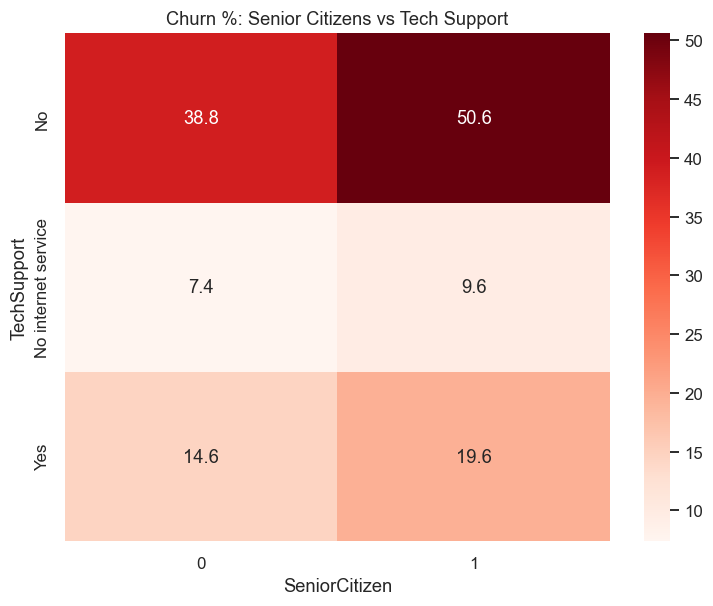

In [86]:
senior_support = (
    df.groupby(['SeniorCitizen', 'TechSupport'])['Churn_Binary']
    .mean()
    .reset_index()
)

senior_support['Churn_Binary'] *= 100

pivot_table = senior_support.pivot(
    index='TechSupport',
    columns='SeniorCitizen',
    values='Churn_Binary'
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Churn %: Senior Citizens vs Tech Support')

plt.show()

- Senior citizens without tech support show extremely high churn.
- Technical guidance is critical for older customers.
- This identifies a highly actionable retention segment

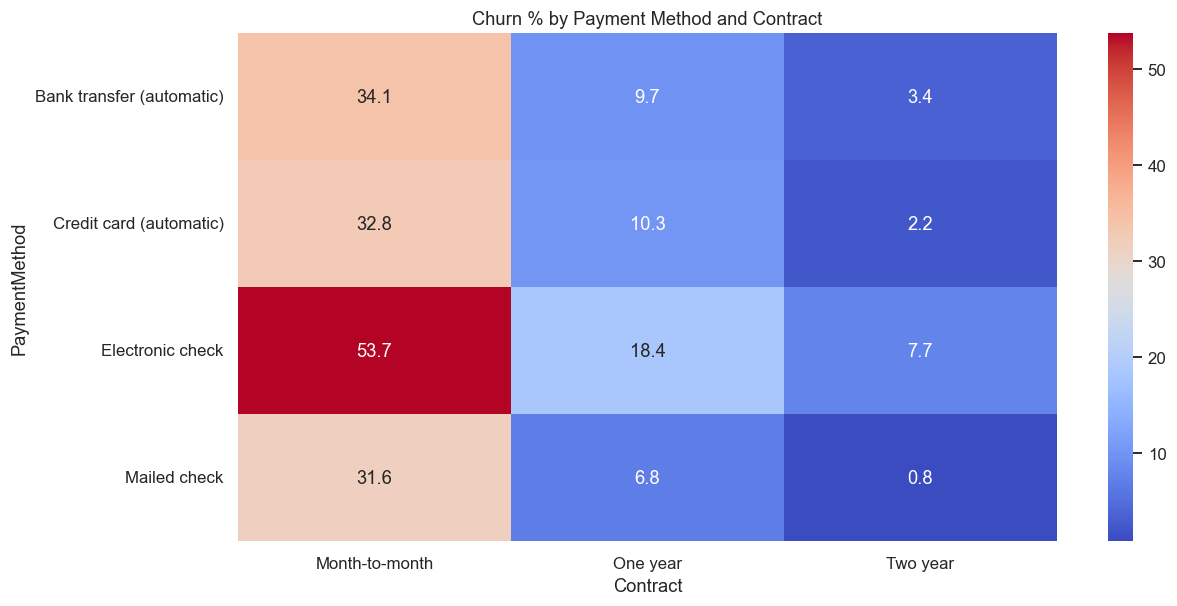

In [87]:
combo = (
    df.groupby(['PaymentMethod', 'Contract'])['Churn_Binary']
    .mean()
    .reset_index()
)

combo['Churn_Binary'] *= 100

pivot_combo = combo.pivot(
    index='PaymentMethod',
    columns='Contract',
    values='Churn_Binary'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_combo,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)

plt.title('Churn % by Payment Method and Contract')

plt.show()

- Electronic check + month-to-month customers are extremely unstable.
- Long-term contracts reduce churn regardless of payment method.
- Commitment structure dominates customer stability.

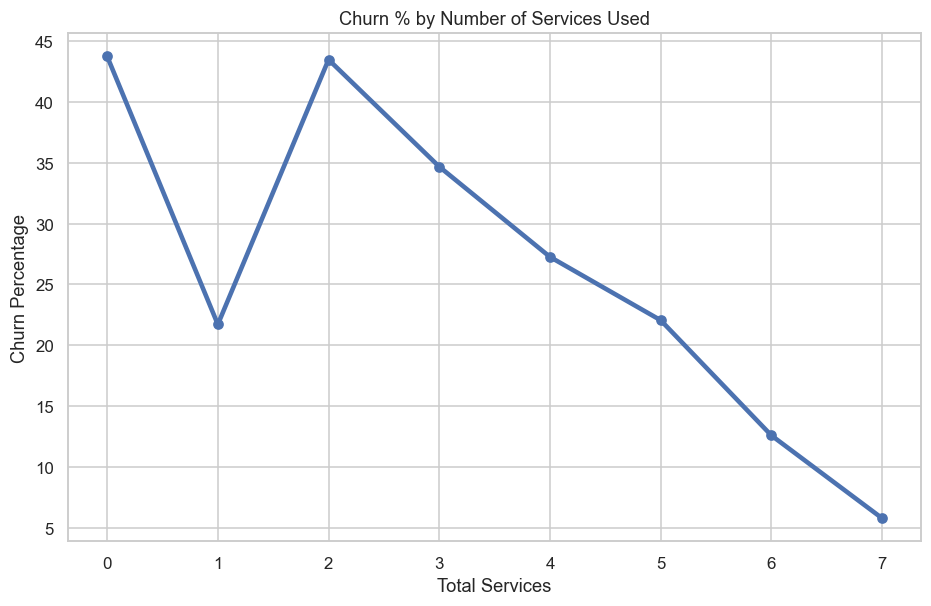

In [88]:
services = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = (
    df[services] == 'Yes'
).sum(axis=1)

service_churn = (
    df.groupby('TotalServices')['Churn_Binary']
    .mean() * 100
)

plt.figure(figsize=(10,6))

service_churn.plot(
    marker='o',
    linewidth=3
)

plt.title('Churn % by Number of Services Used')
plt.ylabel('Churn Percentage')
plt.xlabel('Total Services')

plt.grid(True)

plt.show()

- Customers with very few services churn the most.
- engagement strongly improves retention.
- Multi-service customers become more dependent on the provider.
- Cross-selling services can reduce churn significantly.

# Core Churn Drivers:
1. **Contract Type**

Month-to-month contracts are the strongest churn risk factor.

2. **Customer Tenure**

New customers are significantly more likely to leave.

3. **Monthly Charges**

Higher monthly pricing increases churn probability.

4. **Internet Service**

Fiber optic users experience disproportionately high churn.

5. **Payment Behavior**

Electronic check customers are less stable.

6. **Value-Added Services**

Online security and tech support reduce churn.

# Hidden Patterns Revealed:
1. Support Services Are Retention Drivers

Online security and tech support dramatically reduce churn.

2. Customers using multiple services become significantly more loyal.

3. Elderly Customers Need Support

Senior citizens require stronger technical assistance.

4. Family Structure Impacts Stability

Customers with partners/dependents are less likely to leave.

# REPORT
-The exploratory data analysis reveals that customer churn is primarily driven by contract flexibility, customer tenure, pricing pressure, and service type.

- Customers on month-to-month contracts exhibit substantially higher churn rates compared to long-term contract customers. Low-tenure customers represent the most vulnerable segment, indicating that early-stage customer retention is critical.

- Monthly charges show a positive relationship with churn, suggesting that customers paying higher fees are more likely to leave, especially during the early lifecycle stage.

- Fiber optic internet users  unexpectedly show high churn behavior despite being premium-service customers,  indicating dissatisfaction related to pricing or service quality.

- Payment behavior also plays a major role. Customers using electronic check payment methods churn more frequently than customers using automated payment systems.

- Additionally, customers subscribed to support-oriented services such as online security and technical support exhibit stronger retention behavior, highlighting the importance of value-added services in customer loyalty.

**Final Conclusion**

- Customer churn is not caused by a single variable but by the interaction of pricing, tenure, contract commitment, and service experience.

- The most vulnerable customer segment is:

 Month-to-month + Fiber Optic + High Monthly Charges + Low Tenure.

# Business Recommendations:
- Focusing  retention campaigns on new customers within the first 6 months.
- Encourage long-term contracts through discounts ore cross line service.
- Promote automatic payment enrollment.
- technical support services.
Monitor high monthly charge customers proactively.